## Notebook Navigation

1. [Executive Summary](#1-executive-summary)
2. [Project Objective and User Benefit](#2-project-objective-and-user-benefit)
3. [Study Area: Washington, DC](#3-study-area-washington-dc)
4. [Data Sources and Assumptions](#4-data-sources-and-assumptions)
5. [Environment Setup and Library Imports](#5-environment-setup-and-library-imports)
6. [Define Project Paths](#6-define-project-paths)
7. [Data Acquisition](#7-data-acquisition)
8. [Exploratory Spatial Visualization](#8-exploratory-spatial-visualization)
9. [Coordinate Reference System Strategy](#9-coordinate-reference-system-strategy)
10. [EV Charger Accessibility Coverage](#10-ev-charger-accessibility-coverage)
11. [Initial Underserved Area Detection](#11-initial-underserved-area-detection)
12. [Terrain Constraint Analysis](#12-terrain-constraint-analysis)
13. [Terrain-Aware Priority Scoring Model](#13-terrain-aware-priority-scoring-model)
14. [Analytical Results and Interpretation](#14-analytical-results-and-interpretation)
15. [Export Final GIS Layers](#15-export-final-gis-layers)
16. [Interactive Map](#16-interactive-map)
17. [Key Planning and Infrastructure Findings](#17-key-planning-and-infrastructure-findings)
18. [Limitations](#18-limitations)
19. [Future Improvements](#19-future-improvements)

## 1. Executive Summary <a id='1-executive-summary'></a>

This project analyzes EV charging accessibility in Washington, DC using open-source geospatial tools and public data. The goal is to identify underserved areas where residents, commuters, or planners may face limited access to EV charging infrastructure.

The workflow combines EV charging station data, spatial coverage analysis, terrain constraints, and priority scoring to support infrastructure planning decisions.

The final deliverables include cleaned GIS layers, accessibility maps, underserved-area outputs, and an interactive map suitable for a GitHub portfolio.

## Why This Project Matters

As electric vehicle adoption increases, equitable access to charging infrastructure becomes increasingly important. Some communities may have limited nearby charging options despite population density, transportation demand, or urban accessibility constraints.

This project demonstrates how open-source GIS and Python-based geospatial workflows can be used to identify underserved areas and support infrastructure planning decisions through reproducible spatial analysis.

## Notebook Metadata

| Item | Value |
|---|---|
| Project | EV Charging Gap Analyzer |
| Study Area | Washington, DC |
| Workflow Type | GIS Accessibility and Infrastructure Gap Analysis |
| Development Environment | JupyterLab + Python |
| Primary Libraries | GeoPandas, Rasterio, Requests, Folium |
| Data Source | NREL Alternative Fuel Stations API |
| Initial Coordinate System | EPSG:4326 (WGS84 Geographic Coordinates) |
| Planned Projected CRS | To be defined during spatial analysis |
| Output Formats | GeoJSON, Maps, Interactive Web Visualization |
| Author | Nahid Mozhdehi |

## 2. Project Objective and User Benefit <a id='2-project-objective-and-user-benefit'></a>

The objective is to build a reproducible Python-based GIS workflow that identifies areas with limited EV charging accessibility.

Primary use cases include:

- identifying underserved neighborhoods for EV infrastructure expansion
- evaluating charging accessibility using spatial analysis workflows
- supporting infrastructure planning and investment prioritization
- comparing charger distribution against transportation and terrain constraints

## 3. Study Area: Washington, DC <a id='3-study-area-washington-dc'></a>

Washington, DC was selected because it has a dense urban environment, strong public open data availability, transportation relevance, and clear planning value.

The city is also small enough for efficient local analysis while still complex enough to demonstrate real GIS problem-solving.

## 4. Data Sources and Assumptions <a id='4-data-sources-and-assumptions'></a>

This project is designed to use free and publicly available data sources.

Planned data sources include:

- EV charging stations from a public REST API
- Washington, DC boundary data from open data sources
- Census or population data for demand estimation
- OpenStreetMap road data for transportation context
- USGS 3DEP 1/3 arc-second DEM data for terrain and slope analysis

DEM files used locally:

- `USGS_13_n39w077_20260407.tif`
- `USGS_13_n39w078_20260407.tif`

These DEM tiles are stored locally in `data/raw/dem/` and are intentionally excluded from GitHub because raster files are large. The data can be downloaded from The National Map Downloader:

https://apps.nationalmap.gov/downloader

Product used: USGS 3DEP 1/3 arc-second DEM.

Assumptions will be documented clearly so the analysis remains transparent and reproducible.

### Analytical Assumptions

Several simplifying assumptions are used throughout this exploratory workflow:

- accessibility is approximated using Euclidean buffers
- charger demand is not modeled directly
- the current study boundary uses a temporary convex hull extent
- terrain influence is simplified using generalized slope classes
- infrastructure suitability is not validated against zoning or land-use constraints

These assumptions are intentionally documented to maintain analytical transparency and avoid overstating the results.

## Geospatial Design Principles

This project follows several geospatial and reproducibility principles:

- modular workflow organization
- reproducible data acquisition
- separation of notebook orchestration and reusable package logic
- CRS-aware spatial analysis
- portable output formats
- transparent data assumptions
- scalable geospatial processing practices

The notebook is designed primarily for workflow orchestration, interpretation, and visualization, while reusable logic will later be migrated into Python package modules.

## Workflow Overview

| Phase | Technical Objective |
|---|---|
| Data Acquisition | Retrieve EV charging infrastructure data from a public REST API |
| Data Validation | Validate API responses and inspect infrastructure attributes |
| Spatial Conversion | Convert tabular records into spatial point geometries |
| CRS Strategy | Reproject datasets for accurate distance-based analysis |
| Exploratory Spatial Analysis | Visualize and inspect infrastructure distribution patterns |
| Accessibility Modeling | Generate EV charger accessibility coverage zones |
| Terrain Integration | Incorporate DEM-derived slope and terrain constraints |
| Gap Detection | Identify underserved geographic areas |
| Priority Scoring | Rank candidate areas using accessibility and terrain metrics |
| Output Generation | Export GIS layers, maps, and interactive web visualizations |

## 5. Environment Setup and Library Imports <a id='5-environment-setup-and-library-imports'></a>

In [1]:
# Import required Python libraries

# Standard library
from pathlib import Path
import os
from pathlib import Path

# Data analysis
import pandas as pd
import numpy as np

# API requests
import requests

# Vector GIS
import geopandas as gpd
from shapely.geometry import Point

# Raster GIS
import rasterio

# Visualization
import matplotlib.pyplot as plt
import folium

## 6. Define Project Paths <a id='6-define-project-paths'></a>

In [2]:
# 6.1: Define project folder paths

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_FINAL = PROJECT_ROOT / "data" / "final"

OUTPUTS = PROJECT_ROOT / "outputs"
OUTPUT_MAPS = OUTPUTS / "maps"
OUTPUT_TABLES = OUTPUTS / "tables"

for folder in [
    DATA_RAW,
    DATA_PROCESSED,
    DATA_FINAL,
    OUTPUTS,
    OUTPUT_MAPS,
    OUTPUT_TABLES
]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data folder: {DATA_RAW}")
print(f"Processed data folder: {DATA_PROCESSED}")
print(f"Final data folder: {DATA_FINAL}")
print(f"Map outputs folder: {OUTPUT_MAPS}")
print(f"Table outputs folder: {OUTPUT_TABLES}")

Project root: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer
Raw data folder: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/data/raw
Processed data folder: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/data/processed
Final data folder: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/data/final
Map outputs folder: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/outputs/maps
Table outputs folder: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/outputs/tables


## 7. Data Acquisition: Fetch EV Charging Station Data from a Free REST API <a id='7-data-acquisition'></a>

This section retrieves EV charging station data using a public REST API. Using an API instead of manually downloading a file makes the workflow more reproducible and closer to a real geospatial process.

For this project, EV station data will be requested for Washington, DC and converted into a GeoDataFrame so it can be used for spatial analysis.

### Technical Notes

- The API response is returned in JSON format.
- Geographic coordinates are converted into spatial point geometries.
- The initial coordinate reference system is EPSG:4326 because the API provides longitude and latitude coordinates.
- Geographic CRS values are appropriate for storage and visualization but not for distance-based calculations.
- Later sections will reproject the dataset into a projected CRS suitable for spatial accessibility analysis in the Washington, DC region.

### 7.1 Define EV Charging Station API Request Settings

This step defines the REST API endpoint and query parameters used to retrieve EV charging station records for Washington, DC.

The request is limited to electric charging infrastructure and uses the District of Columbia as the study area filter.

In [3]:
API_URL = "https://developer.nrel.gov/api/alt-fuel-stations/v1.json"

params = {
    "fuel_type": "ELEC",
    "state": "DC",
    "country": "US",
    "limit": "all",
    "api_key": "DEMO_KEY"
}

print("API endpoint configured.")

API endpoint configured.


### 7.2 Send Request to the REST API

The API request retrieves EV charging station records for Washington, DC using the configured query parameters.

This step validates:
- API connectivity
- request parameter structure
- response availability
- reproducibility of data acquisition

In [4]:
response = requests.get(API_URL, params=params, timeout=30)

print(f"Status code: {response.status_code}")
print(f"Request URL: {response.url}")

Status code: 200
Request URL: https://developer.nrel.gov/api/alt-fuel-stations/v1.json?fuel_type=ELEC&state=DC&country=US&limit=all&api_key=DEMO_KEY


### API Request Result

The request completed successfully with a valid HTTP response.

At this stage:
- EV charging infrastructure records have been retrieved successfully
- the response structure can now be validated
- the dataset is ready for transformation into a tabular format

### 7.3 Validate the API Response

In [5]:
# Validate the API response

if response.status_code != 200:
    raise RuntimeError(f"API request failed with status code {response.status_code}")

data = response.json()

print("Top-level response keys:")
print(data.keys())

Top-level response keys:
dict_keys(['station_locator_url', 'total_results', 'station_counts', 'fuel_stations'])


### 7.4 Extract Station Records from the API Response

In [6]:
#Extract station records from the JSON response

stations = data.get("fuel_stations", [])

print(f"Number of EV charging station records returned: {len(stations)}")

Number of EV charging station records returned: 412


### 7.5 Convert Station Records into a Pandas DataFrame

In [7]:
stations_df = pd.DataFrame(stations)

print(f"Rows: {stations_df.shape[0]}")
print(f"Columns: {stations_df.shape[1]}")

stations_df.head()

Rows: 412
Columns: 76


,access_code,access_days_time,access_detail_code,cards_accepted,date_last_confirmed,expected_date,fuel_type_code,groups_with_access_code,id,maximum_vehicle_class,...,rd_max_biodiesel_level,nps_unit_name,access_days_time_fr,intersection_directions_fr,bd_blends_fr,groups_with_access_code_fr,ev_pricing_fr,ev_charging_units,ev_network_ids,federal_agency
0,public,Restricted to garage hours; pay lot; leave key,NaN,NaN,2023-08-10,NaN,ELEC,Public,43836,LD,...,None,NaN,None,None,None,Public,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN
1,private,NaN,NaN,NaN,2024-01-09,NaN,ELEC,Private,48074,NaN,...,None,NaN,None,None,None,Privé,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN
2,private,For tenant and guest use only,NaN,NaN,2025-09-12,NaN,ELEC,Private,51735,LD,...,None,NaN,None,None,None,Privé,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN
3,public,24 hours daily,NaN,NaN,2026-05-06,NaN,ELEC,Public,57221,NaN,...,None,National Capital Parks,None,None,None,Public,None,"[{'network': 'ChargePoint Network', 'connector...","{'station': ['USCPIL716391'], 'posts': ['28489...",NaN
4,public,24 hours daily,NaN,NaN,2026-05-06,NaN,ELEC,Public,64548,NaN,...,None,NaN,None,None,None,Public,None,"[{'network': 'ChargePoint Network', 'connector...","{'station': ['USCPIL748021'], 'posts': ['99427...",NaN


### Dataset Inspection Observations

The API response returned 412 EV charging station records and 76 attributes.

The dataset includes:
- charger accessibility information
- charging network metadata
- charger counts by level
- facility classifications
- geographic coordinates
- operational metadata

Many attributes are not required for accessibility modeling, so subsequent steps focus on selecting fields relevant to spatial analysis and infrastructure evaluation.

### 7.6 Review available fields

In [8]:
stations_df.columns.tolist()

['access_code',
 'access_days_time',
 'access_detail_code',
 'cards_accepted',
 'date_last_confirmed',
 'expected_date',
 'fuel_type_code',
 'groups_with_access_code',
 'id',
 'maximum_vehicle_class',
 'open_date',
 'owner_type_code',
 'related_stations',
 'restricted_access',
 'status_code',
 'funding_sources',
 'facility_type',
 'station_name',
 'station_phone',
 'updated_at',
 'geocode_status',
 'latitude',
 'longitude',
 'city',
 'country',
 'intersection_directions',
 'plus4',
 'state',
 'street_address',
 'zip',
 'bd_blends',
 'cng_dispenser_num',
 'cng_fill_type_code',
 'cng_has_rng',
 'cng_psi',
 'cng_renewable_source',
 'cng_total_compression',
 'cng_total_storage',
 'cng_vehicle_class',
 'e85_blender_pump',
 'e85_other_ethanol_blends',
 'ev_connector_types',
 'ev_dc_fast_num',
 'ev_level1_evse_num',
 'ev_level2_evse_num',
 'ev_network',
 'ev_network_web',
 'ev_other_evse',
 'ev_pricing',
 'ev_renewable_source',
 'ev_workplace_charging',
 'hy_is_retail',
 'hy_pressures',
 'hy_

### 7.7 Select useful fields for this project

In [9]:
selected_columns = [
    "station_name",
    "street_address",
    "city",
    "state",
    "zip",
    "latitude",
    "longitude",
    "ev_network",
    "ev_level1_evse_num",
    "ev_level2_evse_num",
    "ev_dc_fast_num",
    "access_code",
    "facility_type"
]

available_columns = [col for col in selected_columns if col in stations_df.columns]

ev_stations_clean = stations_df[available_columns].copy()

ev_stations_clean.head()

,station_name,street_address,city,state,zip,latitude,longitude,ev_network,ev_level1_evse_num,ev_level2_evse_num,ev_dc_fast_num,access_code,facility_type
0,One Parking,555 12th St NW,Washington,DC,20004,38.896703,-77.027621,Non-Networked,NaN,13.0,NaN,public,PAY_GARAGE
1,Florida Power & Light - Washington DC Office,801 Pennsylvania Ave NW,Washington,DC,20004,38.894354,-77.023723,Non-Networked,NaN,1.0,NaN,private,UTILITY
2,Maritime Plaza,1201 M St SE,Washington,DC,20003,38.875930,-76.989468,Non-Networked,NaN,2.0,NaN,private,OFFICE_BLDG
3,WASH HARBOUR STATION 1,3000 K St NW,Washington,DC,20007,38.901780,-77.059732,ChargePoint Network,NaN,2.0,NaN,public,NaN
4,TOWER COMPANIES 1828 L ST NW #1,1828 L St NW,Washington,DC,20036,38.903466,-77.042898,ChargePoint Network,NaN,2.0,NaN,public,NaN


### 7.8 Check missing coordinate values

In [10]:
missing_coordinates = ev_stations_clean[["latitude", "longitude"]].isna().sum()

print("Missing coordinate values:")
print(missing_coordinates)

Missing coordinate values:
latitude     0
longitude    0
dtype: int64


### 7.9 Remove records without valid coordinates

In [11]:
ev_stations_clean = ev_stations_clean.dropna(subset=["latitude", "longitude"]).copy()

print(f"Records after removing missing coordinates: {len(ev_stations_clean)}")

Records after removing missing coordinates: 412


### 7.10 Convert EV station table into a GeoDataFrame

In [12]:
ev_stations_gdf = gpd.GeoDataFrame(
    ev_stations_clean,
    geometry=gpd.points_from_xy(
        ev_stations_clean["longitude"],
        ev_stations_clean["latitude"]
    ),
    crs="EPSG:4326"
)

ev_stations_gdf.head()

,station_name,street_address,city,state,zip,latitude,longitude,ev_network,ev_level1_evse_num,ev_level2_evse_num,ev_dc_fast_num,access_code,facility_type,geometry
0,One Parking,555 12th St NW,Washington,DC,20004,38.896703,-77.027621,Non-Networked,NaN,13.0,NaN,public,PAY_GARAGE,POINT (-77.02762 38.8967)
1,Florida Power & Light - Washington DC Office,801 Pennsylvania Ave NW,Washington,DC,20004,38.894354,-77.023723,Non-Networked,NaN,1.0,NaN,private,UTILITY,POINT (-77.02372 38.89435)
2,Maritime Plaza,1201 M St SE,Washington,DC,20003,38.875930,-76.989468,Non-Networked,NaN,2.0,NaN,private,OFFICE_BLDG,POINT (-76.98947 38.87593)
3,WASH HARBOUR STATION 1,3000 K St NW,Washington,DC,20007,38.901780,-77.059732,ChargePoint Network,NaN,2.0,NaN,public,NaN,POINT (-77.05973 38.90178)
4,TOWER COMPANIES 1828 L ST NW #1,1828 L St NW,Washington,DC,20036,38.903466,-77.042898,ChargePoint Network,NaN,2.0,NaN,public,NaN,POINT (-77.0429 38.90347)


### 7.11 Confirm spatial metadata

In [13]:
print(f"CRS: {ev_stations_gdf.crs}")
print(f"Geometry type: {ev_stations_gdf.geometry.geom_type.unique()}")
print(f"Total EV stations: {len(ev_stations_gdf)}")

CRS: EPSG:4326
Geometry type: <StringArray>
['Point']
Length: 1, dtype: str
Total EV stations: 412


### 7.12 Save raw EV station data for reproducibility

In [14]:
raw_output_path = DATA_RAW / "dc_ev_charging_stations_raw.geojson"

ev_stations_gdf.to_file(raw_output_path, driver="GeoJSON")

print(f"Saved raw EV station layer to: {raw_output_path}")

Saved raw EV station layer to: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/data/raw/dc_ev_charging_stations_raw.geojson


## 7.13 Initial Data Quality Assessment

Before beginning spatial analysis, the EV charging dataset should be reviewed for attribute completeness, infrastructure accessibility characteristics, and potential distribution biases.

This step helps identify:
- missing attribute values
- public versus private charger distribution
- charger network concentration
- facility-type patterns
- potential data quality limitations

In [15]:
# 7.13: Review missing values

missing_values = ev_stations_clean.isna().sum().sort_values(ascending=False)

missing_values.head(10)

ev_level1_evse_num    402
ev_dc_fast_num        401
facility_type         257
ev_level2_evse_num     13
street_address          1
station_name            0
city                    0
state                   0
zip                     0
latitude                0
dtype: int64

In [16]:
# 7.14: Review charger accessibility distribution

ev_stations_clean["access_code"].value_counts()

access_code
public     329
private     83
Name: count, dtype: int64

In [17]:
# 7.15: Review charger network distribution

ev_stations_clean["ev_network"].value_counts().head(10)

ev_network
Blink Network          125
ChargePoint Network    102
Non-Networked           78
Tesla Destination       44
AMPUP                   19
FLASH                   14
EV Connect               7
Tesla                    4
VIALYNK                  4
LOOP                     4
Name: count, dtype: int64

In [18]:
# 7.16: Review facility type distribution

ev_stations_clean["facility_type"].value_counts().head(10)

facility_type
FED_GOV                64
HOTEL                  24
PARKING_GARAGE         19
PUBLIC                 13
OFFICE_BLDG             8
NATL_PARK               6
MULTI_UNIT_DWELLING     5
OTHER                   4
PAY_GARAGE              3
UTILITY                 1
Name: count, dtype: int64

### Initial Data Quality Observations

The dataset includes a mixture of public and private charging infrastructure, with visible concentration among several dominant charging networks.

Several facility-type values contain missing records, which may affect later infrastructure categorization analysis. However, the spatial coordinate fields appear complete and suitable for spatial processing.

## 8. Exploratory Spatial Visualization <a id='8-exploratory-spatial-visualization'></a>

Before beginning accessibility analysis, the EV charging stations are visualized spatially to validate geographic coverage and inspect general distribution patterns across Washington, DC.

This exploratory visualization serves several purposes:

- validates successful geometry creation
- verifies expected geographic extent
- identifies preliminary infrastructure clustering patterns
- supports early quality assurance of spatial data
- provides an initial understanding of spatial accessibility distribution

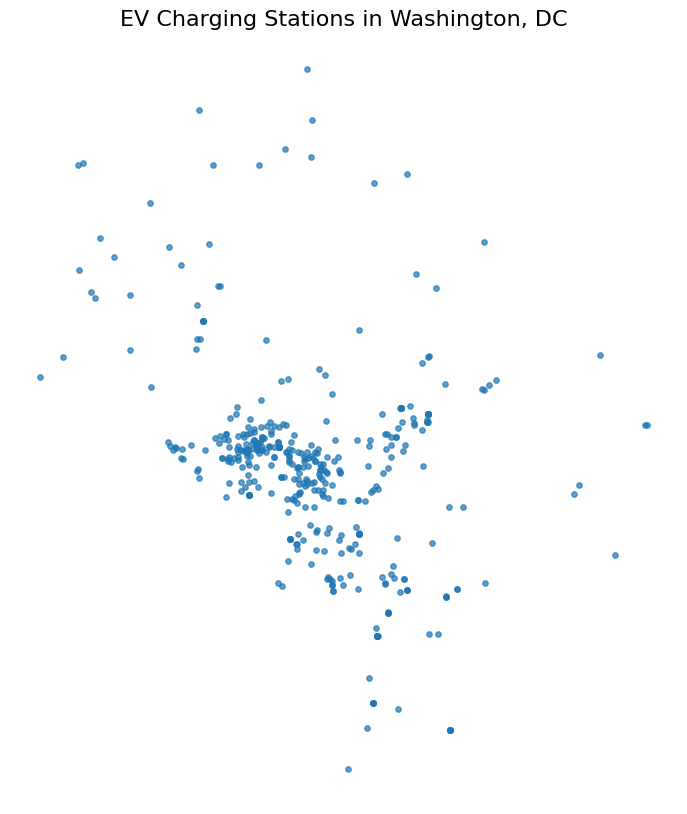

In [19]:
# 8.1: Create an initial map of EV charging stations

fig, ax = plt.subplots(figsize=(10, 10))

ev_stations_gdf.plot(
    ax=ax,
    markersize=15,
    alpha=0.7
)

ax.set_title(
    "EV Charging Stations in Washington, DC",
    fontsize=16
)

ax.set_axis_off()

plt.show()

### Visualization Notes

This initial visualization intentionally uses a lightweight plotting approach to validate geometry creation and spatial extent before introducing more advanced cartographic styling and basemap integration.

Early-stage exploratory visualization is an important quality assurance step in GIS workflows because it helps identify projection issues, invalid geometries, and unexpected spatial patterns before downstream analysis begins.

### 8.1 Initial Spatial Observations

The initial visualization indicates that EV charging infrastructure is concentrated in central and northwestern areas of Washington, DC, with visible clustering near commercial and high-density mixed-use areas.

This preliminary distribution suggests that accessibility may vary significantly across neighborhoods, supporting the need for further underserved-area analysis.

In [20]:
# 8.2: Review spatial extent of EV charging infrastructure

ev_stations_gdf.total_bounds

array([-77.095715 ,  38.8401346, -76.94095  ,  38.9790239])

### Spatial Extent Validation

The spatial extent confirms that all EV charging station geometries fall within the expected Washington, DC region.

Bounding-box validation is a useful GIS quality assurance technique because it can quickly reveal coordinate errors, projection issues, or invalid geographic records.

### Scalability Considerations

Although this project currently focuses on Washington, DC, the workflow is designed to scale to larger metropolitan regions and statewide infrastructure datasets.

For larger datasets, additional optimizations such as spatial indexing, vectorized operations, and tiled raster processing may become important for maintaining performance.

## 8.2 GIS and Accessibility Analysis Considerations

Several GIS-specific considerations influence the design of this workflow:

- geographic coordinate systems are unsuitable for distance-based calculations
- infrastructure accessibility is influenced by both spatial proximity and terrain
- public versus private charging infrastructure may affect practical accessibility
- infrastructure clustering patterns can introduce spatial bias
- reproducible CRS handling is critical for reliable geospatial analysis

These considerations guide the selection of spatial analysis methods used throughout the project.

## 9. Coordinate Reference System Strategy <a id='9-coordinate-reference-system-strategy'></a>

The initial EV charging station dataset uses EPSG:4326 because the source REST API provides geographic longitude and latitude coordinates.

Although geographic coordinate systems are appropriate for storage and visualization, they are not suitable for distance-based spatial analysis because measurements are represented in angular units (degrees) rather than linear units such as meters or feet.

Spatial operations planned later in this workflow — including buffer generation, accessibility analysis, and proximity calculations — require a projected coordinate reference system with accurate local distance measurements.

For the Washington, DC region, a projected CRS will be selected to support reliable spatial analysis and minimize distortion.

### 9.1 Geographic vs Projected Coordinate Systems

Coordinate reference systems influence how spatial data is represented, measured, and analyzed.

This workflow distinguishes between:

- geographic coordinate systems used for global coordinate representation
- projected coordinate systems used for local spatial analysis and measurement

Key differences include:

| CRS Type | Units | Typical Use Case |
|---|---|---|
| Geographic CRS | Degrees        | Storage, GPS, web mapping       |
| Projected CRS  | Meters or feet | Distance, area, buffer analysis |

Using an inappropriate CRS for accessibility analysis can introduce inaccurate distance calculations and misleading spatial results.

### 9.2 Candidate Projected Coordinate Systems for Washington, DC

Several projected coordinate systems are commonly used for regional spatial analysis in the Washington, DC area.

Potential candidates include:

| CRS | Description |
|---|---|
| EPSG:3857 | Web Mercator (common for visualization but not ideal for accurate distance analysis) |
| EPSG:26918 | NAD83 / UTM Zone 18N |
| EPSG:2248 | NAD83 / Maryland StatePlane (US Feet) |

For this project, EPSG:26918 will be used because:

- it provides meter-based units
- it is widely used for regional GIS analysis
- distortion is minimal for the Washington, DC area
- it is appropriate for accessibility and buffer calculations

In [21]:
# 9.1: Review current coordinate reference system

print(f"Current CRS: {ev_stations_gdf.crs}")

Current CRS: EPSG:4326


### Current CRS Observation

The EV charging station dataset currently uses EPSG:4326, confirming that the spatial coordinates are stored as geographic longitude and latitude values.

The next step reprojects the dataset into a projected CRS suitable for local distance-based spatial analysis.

In [22]:
#  9.2: Reproject EV charging stations to a projected CRS

PROJECTED_CRS = "EPSG:26918"

evStationsProjectedGdf = ev_stations_gdf.to_crs(PROJECTED_CRS)

print(f"Projected CRS: {evStationsProjectedGdf.crs}")

Projected CRS: EPSG:26918


### 9.3 Why Reprojection Matters

Reprojecting the dataset changes the coordinate representation from geographic degrees to projected linear units.

This is essential because:

- buffer distances require linear measurement units
- accessibility calculations depend on accurate distance representation
- projected CRS values reduce distortion during local spatial analysis
- terrain and infrastructure overlays require consistent spatial reference systems

Without reprojection, later accessibility results could become spatially inaccurate.

In [23]:
# 9.3: Compare geographic and projected coordinate examples

print("Geographic coordinates:")
print(ev_stations_gdf.geometry.iloc[0])

print("\nProjected coordinates:")
print(evStationsProjectedGdf.geometry.iloc[0])

Geographic coordinates:
POINT (-77.027621 38.896703)

Projected coordinates:
POINT (324161.89407885156 4307267.826042438)


### Coordinate Comparison Observation

The projected coordinates now use meter-based values instead of longitude and latitude degrees.

This confirms that the dataset is now prepared for distance-based GIS operations such as:

- charger accessibility buffers
- proximity analysis
- underserved-area detection
- terrain-integrated accessibility modeling

### 9.4 Spatial Analysis Readiness

The EV charging infrastructure dataset has now been successfully transformed into a projected coordinate reference system suitable for distance-based GIS analysis.

At this stage, the workflow is prepared for:

- accessibility buffer generation
- proximity analysis
- infrastructure coverage modeling
- terrain-constrained accessibility evaluation
- underserved-area detection

Ensuring CRS consistency before spatial analysis is a critical GIS practice because downstream accessibility calculations depend on reliable linear distance measurements.

In [24]:
# 9.4: Review projected spatial extent

evStationsProjectedGdf.total_bounds

array([ 318310.29521075, 4300969.59537   ,  331706.2610905 ,
       4316404.17851058])

### Projected Spatial Extent Validation

The projected dataset extent confirms that the EV charging infrastructure has been successfully transformed into the selected projected CRS.

Spatial extent validation is an important GIS quality assurance step because it helps detect:
- invalid projections
- incorrect CRS assignments
- coordinate transformation failures
- unexpected spatial displacement

### Note

Maintaining explicit CRS handling throughout a GIS workflow is critical for reproducibility and spatial accuracy.

Professional geospatial workflows should avoid:
- implicit CRS assumptions
- mixed spatial reference systems
- distance calculations in geographic coordinates
- undocumented projection transformations

Explicit CRS validation improves workflow reliability and analytical transparency.

## 10. EV Charger Accessibility Coverage <a id='10-ev-charger-accessibility-coverage'></a>

This section models preliminary EV charging accessibility coverage across Washington, DC using distance-based spatial analysis.

Accessibility coverage analysis helps estimate which geographic areas are located within a reasonable proximity to existing charging infrastructure.

For this workflow, charger coverage zones will initially be modeled using buffer analysis.

Although network-based service areas may provide more precise travel accessibility modeling, buffer-based analysis provides:

- a computationally efficient baseline
- interpretable spatial coverage zones
- rapid exploratory accessibility assessment
- a reproducible foundation for future enhancement

The resulting coverage areas will later support:
- underserved-area detection
- accessibility gap analysis
- terrain-constrained accessibility evaluation
- infrastructure prioritization workflows

### 10.1 Accessibility Modeling Assumptions

Accessibility analysis requires several simplifying assumptions.

For this initial workflow:

- Level 2 charging infrastructure will use a generalized accessibility radius
- Euclidean buffer distance is used as an approximation of accessibility
- road network constraints are not yet incorporated
- terrain influence will be integrated in later sections

These assumptions are intentionally documented to maintain analytical transparency and reproducibility.

### Accessibility Modeling Note

The current workflow uses Euclidean buffer analysis rather than transportation-network service areas.

Euclidean buffers provide a simplified accessibility approximation because they measure straight-line distance rather than actual travel distance along roads or pedestrian networks.

Despite this limitation, buffer analysis remains useful for exploratory accessibility modeling because it is computationally efficient, interpretable, and reproducible.

In [25]:
# 10.1: Define accessibility buffer distance

BUFFER_DISTANCE_METERS = 800 # 800 meters ≈ 1/2 mile

print(f"Accessibility buffer distance: {BUFFER_DISTANCE_METERS} meters")

Accessibility buffer distance: 800 meters


### Buffer Distance Selection

An 800-meter accessibility distance, approximately one-half mile, is used as an initial approximation of EV charging accessibility coverage.

The selected distance is intended to represent:
- short urban driving accessibility
- neighborhood-scale infrastructure access
- generalized proximity-based accessibility

The distance threshold can later be refined using:
- transportation network analysis
- charger type differentiation
- population density
- terrain-adjusted travel impedance

In [26]:
# Cell 10.2: Generate EV charger accessibility buffers

chargerCoverageGdf = evStationsProjectedGdf.copy()

chargerCoverageGdf["geometry"] = chargerCoverageGdf.buffer(
    BUFFER_DISTANCE_METERS
)

print("Accessibility buffers created successfully.")

Accessibility buffers created successfully.


### Accessibility Buffer Generation

Each EV charging station has now been converted into a coverage zone representing approximate accessibility influence.

The resulting polygons represent areas located within the defined accessibility distance of existing charging infrastructure.

These coverage zones provide a simplified representation of spatial accessibility and will support later underserved-area analysis.

In [27]:
# 10.3: Review accessibility coverage geometry types

chargerCoverageGdf.geometry.geom_type.unique()

<StringArray>
['Polygon']
Length: 1, dtype: str

### Geometry Validation

The accessibility layer now contains polygon geometries generated from the original EV charging station point locations.

Geometry validation is an important GIS quality assurance step because downstream overlay operations require valid polygon geometries.

In [28]:
# 10.4: Dissolve overlapping accessibility coverage areas

chargerCoverageDissolvedGdf = chargerCoverageGdf.dissolve()

print("Accessibility coverage dissolved successfully.")

Accessibility coverage dissolved successfully.


### Why Dissolve Coverage Areas

Many EV charging accessibility buffers overlap spatially.

Dissolving overlapping polygons creates a unified accessibility coverage surface that better represents combined infrastructure reach across the study area.

This improves:
- visualization clarity
- overlay analysis efficiency
- underserved-area identification
- spatial interpretation

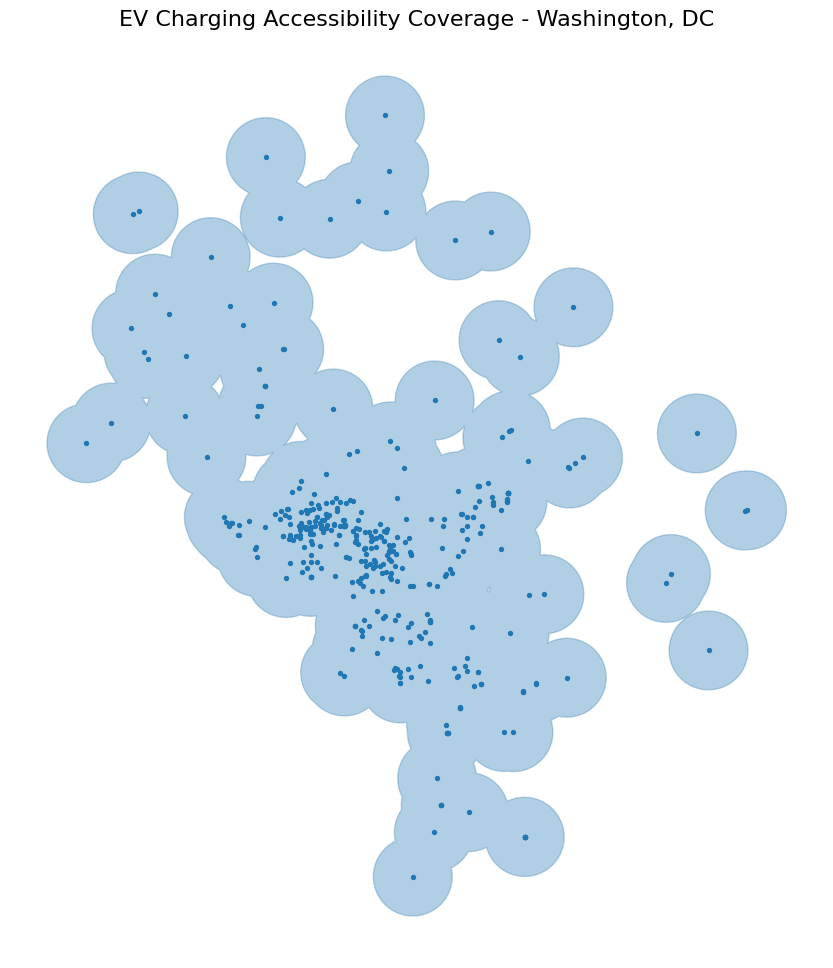

In [29]:
# 10.5: Visualize EV accessibility coverage

fig, ax = plt.subplots(figsize=(12, 12))

chargerCoverageDissolvedGdf.plot(
    ax=ax,
    alpha=0.35,
    edgecolor="steelblue",
    linewidth=1
)

evStationsProjectedGdf.plot(
    ax=ax,
    markersize=8
)

ax.set_title(
    "EV Charging Accessibility Coverage - Washington, DC",
    fontsize=16
)

ax.set_axis_off()

plt.show()

### Accessibility Coverage Observation

The dissolved accessibility surface reveals areas with concentrated charging infrastructure coverage as well as regions with more limited accessibility reach.

Coverage concentration appears strongest in:
- central Washington, DC
- mixed-use commercial corridors
- higher-density transportation areas

Some areas near the outer portions of the current analysis extent appear to have less coverage under the 800-meter buffer assumption.This suggests possible candidate zones for deeper analysis, but final conclusions should wait until an official study boundary, population data, and terrain constraints are added.

In [30]:
# 10.6: Calculate total accessibility coverage area

coverageAreaSqMeters = (
    chargerCoverageDissolvedGdf.geometry.area.iloc[0]
)

coverageAreaSqKilometers = coverageAreaSqMeters / 1_000_000

print(
    f"Estimated accessibility coverage area: "
    f"{coverageAreaSqKilometers:.2f} square kilometers"
)

Estimated accessibility coverage area: 101.82 square kilometers


### Coverage Area Calculation

Estimating total accessibility coverage area provides a quantitative measure of infrastructure reach across the study area.

This metric can later support:
- accessibility comparison workflows
- infrastructure expansion analysis
- underserved-area scoring
- temporal infrastructure monitoring

In [31]:
# 10.7: Export accessibility coverage layer

coverageOutputPath = (
    DATA_PROCESSED /
    "dc_ev_accessibility_coverage.geojson"
)

chargerCoverageDissolvedGdf.to_file(
    coverageOutputPath,
    driver="GeoJSON"
)

print(f"Coverage layer exported to: {coverageOutputPath}")

Coverage layer exported to: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/data/processed/dc_ev_accessibility_coverage.geojson


### Reproducibility and Output Management

Exporting intermediate GIS layers improves workflow reproducibility and supports:

- downstream spatial analysis
- external GIS visualization
- web mapping integration
- quality assurance review
- interoperability with desktop GIS platforms

Portable geospatial output formats improve interoperability between desktop GIS platforms, Python workflows, and web mapping environments.

## 11. Initial Underserved Area Detection <a id='11-initial-underserved-area-detection'></a>

This section creates an initial underserved-area layer using a temporary study boundary. The result should be interpreted as an exploratory service-gap layer, not a final planning boundary analysis.

A later version should replace the temporary boundary with an official Washington, DC boundary or Census geography before final prioritization.

### 11.1 Analytical Approach

The underserved-area workflow follows a simplified spatial overlay methodology:

1. define the Washington, DC study area boundary
2. compare study area extent against charger accessibility coverage
3. identify geographic regions outside accessibility coverage
4. generate candidate underserved polygons
5. prepare underserved areas for later scoring and prioritization

This approach provides an interpretable first-stage accessibility gap model while maintaining reproducibility and computational efficiency.

In [32]:
# 11.1: Define approximate Washington, DC study boundary

studyBoundary = (
    evStationsProjectedGdf
    .geometry
    .union_all()
    .convex_hull
)

print("Study boundary generated successfully.")

Study boundary generated successfully.


### Study Boundary Note

A temporary exploratory study boundary is generated using a convex hull derived from the EV charging station geometries.

The convex hull represents the minimum bounding polygon enclosing the infrastructure extent and provides a lightweight analytical boundary suitable for exploratory accessibility workflows.

This approach is computationally efficient but should not be interpreted as an official administrative or planning boundary.

This provides an approximate regional analysis extent for exploratory accessibility modeling.

In production-level workflows, official administrative boundaries or jurisdiction datasets should be used instead of generalized convex hull geometries.

In [33]:
# 11.2: Convert study boundary into a GeoDataFrame

studyBoundaryGdf = gpd.GeoDataFrame(
    geometry=[studyBoundary],
    crs=PROJECTED_CRS
)

studyBoundaryGdf.head()

,geometry
0,"POLYGON ((324928.791 4300969.595, 318310.295 4..."


In [34]:
# 11.3: Identify underserved geographic areas

underservedAreasGdf = gpd.overlay(
    studyBoundaryGdf,
    chargerCoverageDissolvedGdf,
    how="difference"
)

print("Underserved areas generated successfully.")

Underserved areas generated successfully.


### Difference Overlay Analysis

The spatial difference operation identifies geographic regions located outside the current EV charging accessibility coverage surface.

This workflow is commonly used in GIS infrastructure analysis for:
- service gap detection
- accessibility modeling
- utility coverage analysis
- transportation planning
- infrastructure expansion assessment

In [35]:
# 11.4: Review underserved area geometry types

underservedAreasGdf.geometry.geom_type.unique()

<StringArray>
['MultiPolygon']
Length: 1, dtype: str

### Geometry Validation

The underserved-area layer contains polygon geometries representing candidate accessibility gap regions.

Geometry validation is important before performing:
- overlay analysis
- spatial scoring
- terrain integration
- prioritization workflows

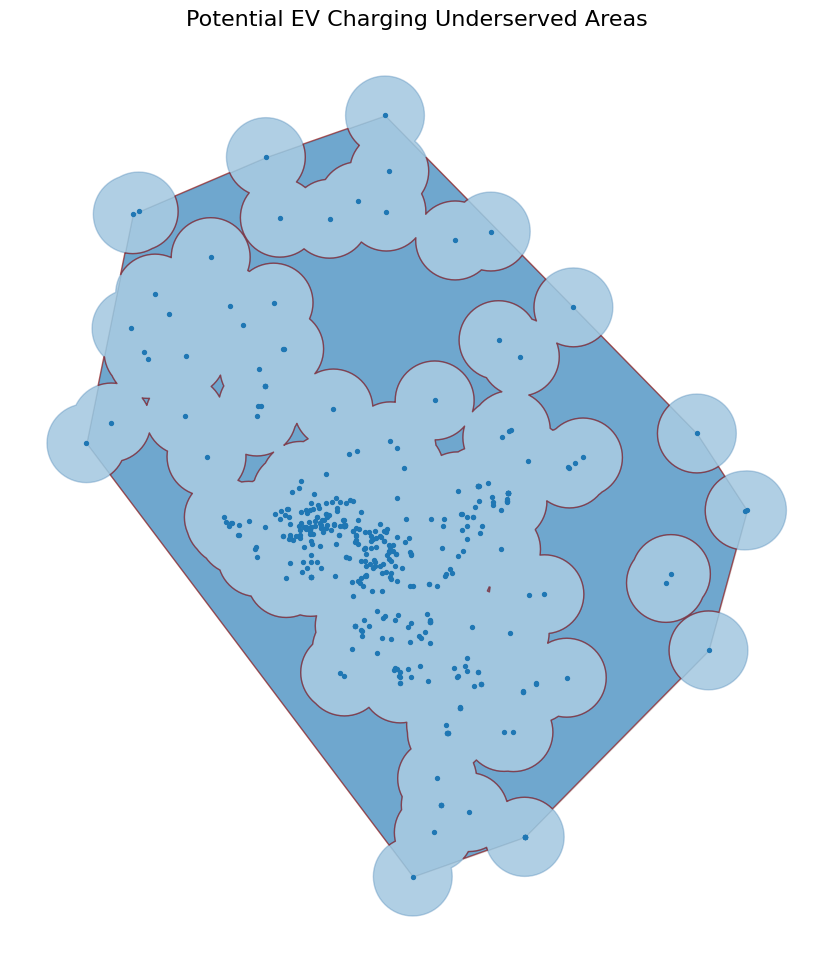

In [36]:
# 11.5: Visualize underserved areas

fig, ax = plt.subplots(figsize=(12, 12))

studyBoundaryGdf.plot(
    ax=ax,
    alpha=0.1,
    edgecolor="black"
)

chargerCoverageDissolvedGdf.plot(
    ax=ax,
    alpha=0.35,
    edgecolor="steelblue",
    linewidth=1
)

underservedAreasGdf.plot(
    ax=ax,
    alpha=0.6,
    edgecolor="darkred",
    linewidth=1
)

evStationsProjectedGdf.plot(
    ax=ax,
    markersize=8
)

ax.set_title(
    "Potential EV Charging Underserved Areas",
    fontsize=16
)

ax.set_axis_off()

plt.show()

### Underserved Area Observation

The visualization highlights geographic regions that currently fall outside the estimated EV charging accessibility coverage surface.

Several candidate gap areas appear near the edge of the temporary study extent. Because this boundary is based on the convex hull of existing stations, these areas should be interpreted as exploratory accessibility gaps rather than final underserved neighborhoods.

A stronger final analysis will use an official Washington, DC boundary, Census geography, and terrain constraints before assigning priority scores.

The analysis also demonstrates that infrastructure accessibility distribution is spatially uneven across the broader study region.

In [37]:
# 11.6: Calculate underserved area statistics

underservedAreasGdf["areaSqKm"] = (
    underservedAreasGdf.geometry.area / 1_000_000
)

underservedAreasGdf[
    ["areaSqKm"]
].describe()

,areaSqKm
count,1.000000
mean,37.023048
std,NaN
min,37.023048
25%,37.023048
50%,37.023048
75%,37.023048
max,37.023048


### Quantitative Gap Assessment

Calculating underserved-area size provides a quantitative foundation for future prioritization workflows.

Potential future enhancements may include:
- population-weighted accessibility scoring
- charger demand estimation
- transportation corridor analysis
- terrain-adjusted accessibility modeling
- socioeconomic overlay analysis

In [38]:
# 11.7: Export underserved-area layer

underservedOutputPath = (
    DATA_PROCESSED /
    "dc_ev_underserved_areas.geojson"
)

underservedAreasGdf.to_file(
    underservedOutputPath,
    driver="GeoJSON"
)

print(f"Underserved layer exported to: {underservedOutputPath}")

Underserved layer exported to: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/data/processed/dc_ev_underserved_areas.geojson


### GIS Output Management

Exporting underserved-area polygons enables interoperability with:

- desktop GIS platforms
- web mapping applications
- infrastructure planning dashboards
- downstream spatial analytics workflows

Structured geospatial output management is an important component of reproducible GIS pipelines.

## 12. Terrain Constraint Analysis <a id='12-terrain-constraint-analysis'></a>

Accessibility is influenced not only by spatial proximity, but also by terrain conditions.

Areas with steep slopes may reduce practical accessibility even when charging infrastructure appears geographically nearby.

This section introduces terrain-derived analysis into the accessibility workflow using digital elevation model (DEM) data and slope calculations.

Integrating terrain constraints improves the realism of accessibility modeling and demonstrates how raster GIS workflows can support infrastructure planning analysis.

### 12.1 Terrain Analysis Objectives

The terrain workflow aims to:

- integrate raster-based GIS analysis into the project
- evaluate terrain influence on accessibility
- identify potentially difficult-access regions
- support terrain-aware underserved-area analysis
- demonstrate raster processing workflows using open-source Python GIS tools

This section also expands the project beyond vector-only GIS analysis by incorporating raster processing concepts.

### 12.2 DEM Processing Strategy

The terrain workflow will use a digital elevation model (DEM) representing elevation values across the study area.

Planned terrain-processing steps include:

1. acquire DEM raster data
2. validate raster spatial reference system
3. derive slope raster
4. classify terrain steepness
5. integrate terrain constraints into underserved-area analysis

Raster-based terrain analysis is commonly used in:
- transportation 
- infrastructure planning
- utility analysis
- environmental modeling
- accessibility studies

### 12.3 DEM Source and Local File Management

The terrain analysis uses USGS 3DEP 1/3 arc-second DEM tiles downloaded from The National Map Downloader.

The local DEM tiles are not committed to GitHub because raster files are large. Instead, the notebook documents the source, filenames, and expected local folder structure so the workflow remains reproducible.

Expected local folder:

`data/raw/dem/`

Expected files:

- `USGS_13_n39w077_20260407.tif`
- `USGS_13_n39w078_20260407.tif`

These two tiles are expected to cover the Washington, DC analysis area and will be merged into a single DEM mosaic before slope analysis.

## 12.4 DEM Loading and Raster Validation

The Washington, DC study area spans multiple DEM tiles, so the terrain workflow begins by loading and merging the required raster datasets into a unified DEM surface.

The terrain analysis uses USGS 3DEP 1/3 arc-second DEM tiles downloaded from The National Map Downloader.

Raster validation is an important GIS step because terrain workflows depend on:

- consistent CRS definitions
- valid raster dimensions
- compatible pixel resolution
- accurate spatial alignment
- reproducible raster processing

In [39]:
# 12.4.1: Import raster processing libraries

from rasterio.merge import merge
from rasterio.plot import show

In [40]:
# 12.4.2: Define DEM file paths

demFolder = DATA_RAW / "dem"

demFilePaths = [
    demFolder / "USGS_13_n39w077_20260407.tif",
    demFolder / "USGS_13_n39w078_20260407.tif"
]

for demPath in demFilePaths:
    print(demPath)

/Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/data/raw/dem/USGS_13_n39w077_20260407.tif
/Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/data/raw/dem/USGS_13_n39w078_20260407.tif


In [41]:
# 12.4.3: Validate DEM file availability

missingDemFiles = [
    demPath for demPath in demFilePaths
    if not demPath.exists()
]

if missingDemFiles:
    raise FileNotFoundError(
        "Missing DEM files: "
        + ", ".join(str(path) for path in missingDemFiles)
    )

print("All expected DEM files are available.")

All expected DEM files are available.


In [42]:
# 12.4.4: Open DEM raster datasets

demDatasets = [
    rasterio.open(path)
    for path in demFilePaths
]

print(f"Loaded DEM tiles: {len(demDatasets)}")

Loaded DEM tiles: 2


In [43]:
# 12.4.5: Review DEM metadata

firstDem = demDatasets[0]

print("CRS:", firstDem.crs)
print("Width:", firstDem.width)
print("Height:", firstDem.height)
print("Resolution:", firstDem.res)
print("Bounds:", firstDem.bounds)

CRS: EPSG:4269
Width: 10812
Height: 10812
Resolution: (9.259259269220298e-05, 9.259259277538025e-05)
Bounds: BoundingBox(left=-77.00055555599346, bottom=37.99944444350716, right=-75.99944444380536, top=39.00055555659457)


In [44]:
# 12.4.6: Merge DEM tiles into a single raster mosaic

mergedDemArray, mergedDemTransform = merge(
    demDatasets
)

print("DEM merge completed successfully.")

DEM merge completed successfully.


### Raster Processing Performance Considerations

Raster workflows are generally more computationally intensive than vector workflows because terrain analysis operates on large pixel grids rather than discrete geometries.

For larger regional studies, additional optimizations may become important, including:

- raster clipping
- tiled processing
- resampling strategies
- memory-aware workflows
- parallelized raster computation

These considerations become increasingly important in production-scale geospatial systems.

In [45]:
# 12.4.7: Define merged DEM metadata

mergedDemCrs = firstDem.crs

mergedDemBounds = rasterio.transform.array_bounds(
    mergedDemArray.shape[1],
    mergedDemArray.shape[2],
    mergedDemTransform
)

print("Merged DEM CRS:", mergedDemCrs)
print("Merged DEM Bounds:", mergedDemBounds)

Merged DEM CRS: EPSG:4269
Merged DEM Bounds: (-78.0005555557936, 37.99944444350717, -75.99944444252971, 39.000555556594584)


### DEM Mosaic Generation

The DEM tiles have now been merged into a unified raster surface covering the broader Washington, DC region.

The merged DEM provides the elevation foundation required for:
- slope derivation
- terrain classification
- terrain-aware accessibility analysis
- future raster overlay workflows

In [46]:
# 12.4.8: Review merged DEM dimensions

print("Merged raster shape:")
print(mergedDemArray.shape)

Merged raster shape:
(1, 10812, 21612)


In [47]:
# 12.4.9: Review merged DEM metadata summary

mergedDemBounds = rasterio.transform.array_bounds(
    mergedDemArray.shape[1],
    mergedDemArray.shape[2],
    mergedDemTransform
)

print("Merged DEM CRS:", firstDem.crs)
print("Merged DEM Resolution:", firstDem.res)
print("Merged DEM Bounds:", mergedDemBounds)

Merged DEM CRS: EPSG:4269
Merged DEM Resolution: (9.259259269220298e-05, 9.259259277538025e-05)
Merged DEM Bounds: (-78.0005555557936, 37.99944444350717, -75.99944444252971, 39.000555556594584)


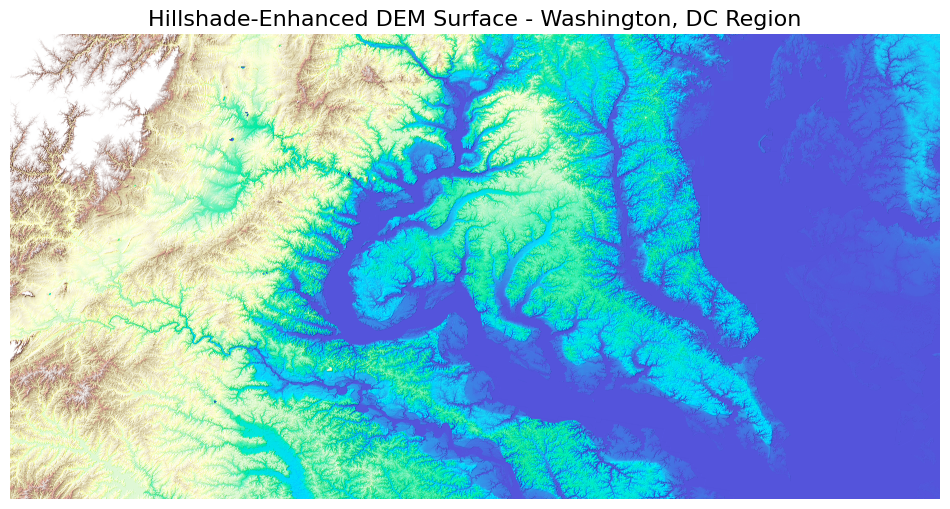

In [48]:
# 12.4.10: Visualize merged DEM using hillshade-enhanced rendering

from matplotlib.colors import LightSource

demVisualizationArray = mergedDemArray[0].astype("float64")

if firstDem.nodata is not None:
    demVisualizationArray[demVisualizationArray == firstDem.nodata] = np.nan

demVisualizationArray[demVisualizationArray < -1000] = np.nan
demVisualizationArray[demVisualizationArray > 10000] = np.nan

demMin = np.nanpercentile(demVisualizationArray, 2)
demMax = np.nanpercentile(demVisualizationArray, 98)

ls = LightSource(
    azdeg=315,
    altdeg=45
)

demRgb = ls.shade(
    demVisualizationArray,
    cmap=plt.cm.terrain,
    vmin=demMin,
    vmax=demMax,
    blend_mode="overlay"
)

fig, ax = plt.subplots(figsize=(12, 12))

ax.imshow(
    demRgb,
    extent=[
        mergedDemBounds[0],
        mergedDemBounds[2],
        mergedDemBounds[1],
        mergedDemBounds[3]
    ]
)

ax.set_title(
    "Hillshade-Enhanced DEM Surface - Washington, DC Region",
    fontsize=16
)

ax.set_axis_off()

plt.show()

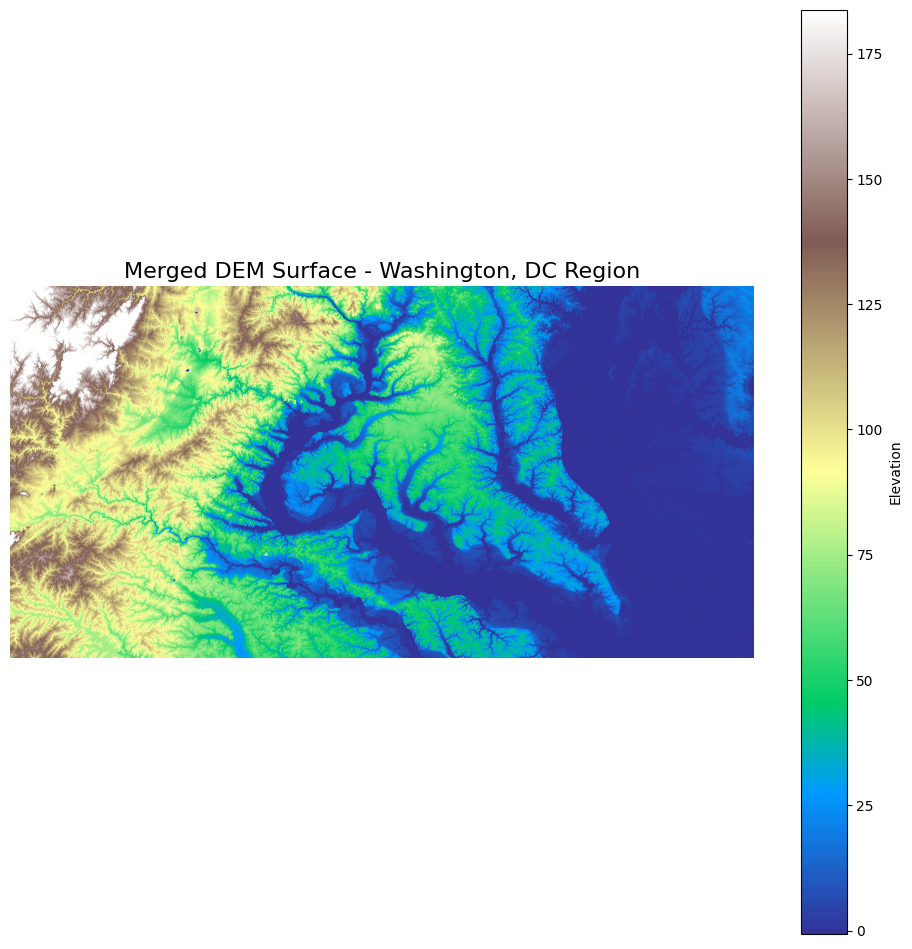

In [49]:
# 12.4.11: Visualize merged DEM

demVisualizationArray = mergedDemArray[0].astype("float64")

if firstDem.nodata is not None:
    demVisualizationArray[demVisualizationArray == firstDem.nodata] = np.nan

demVisualizationArray[demVisualizationArray < -1000] = np.nan
demVisualizationArray[demVisualizationArray > 10000] = np.nan

demMin = np.nanpercentile(demVisualizationArray, 2)
demMax = np.nanpercentile(demVisualizationArray, 98)

fig, ax = plt.subplots(figsize=(12, 12))

demImage = ax.imshow(
    demVisualizationArray,
    cmap="terrain",
    vmin=demMin,
    vmax=demMax,
    extent=[
        mergedDemBounds[0],
        mergedDemBounds[2],
        mergedDemBounds[1],
        mergedDemBounds[3]
    ]
)

ax.set_title(
    "Merged DEM Surface - Washington, DC Region",
    fontsize=16
)

ax.set_axis_off()

plt.colorbar(
    demImage,
    ax=ax,
    label="Elevation"
)

plt.show()

### DEM Visualization Note

DEM rasters often contain nodata pixels or narrow elevation ranges that can reduce visual contrast.

This workflow removes invalid elevation values and uses hillshade-enhanced rendering to improve terrain interpretation. Hillshade visualization is useful for low-relief urban regions because subtle terrain variation may not be obvious with a simple elevation color ramp.

### DEM Visualization Observation

The hillshade-enhanced DEM provides an initial view of terrain variation across the DEM tile mosaic covering the Washington, DC region.

Although elevation variation in Washington, DC is moderate compared to mountainous regions, the shaded relief view makes subtle terrain structure easier to interpret.

This terrain surface provides the raster foundation for slope derivation and terrain-aware accessibility analysis.

### Raster Note

Raster processing workflows introduce additional GIS considerations compared to vector-only analysis workflows.

Important raster considerations include:
- pixel resolution
- CRS consistency
- nodata handling
- raster alignment
- processing performance
- memory management

Explicit raster validation improves terrain-analysis reliability and reproducibility.

## 12.5 Slope Derivation

Slope is derived from the merged DEM to estimate terrain steepness across the study area.

This step converts elevation change into a terrain constraint layer that can later be used to adjust EV charging accessibility analysis.

Slope is important because steep terrain may reduce practical accessibility, especially for walking access, biking access, and neighborhood-scale movement.

In [50]:
# 12.5.1: Import slope processing tools

from rasterio.enums import Resampling
import numpy as np

In [51]:
# 12.5.2: Prepare DEM array for slope calculation

demArray = mergedDemArray[0].astype("float64")

print("DEM array shape:", demArray.shape)
print("Minimum elevation:", np.nanmin(demArray))
print("Maximum elevation:", np.nanmax(demArray))

DEM array shape: (10812, 21612)
Minimum elevation: -62.17776107788086
Maximum elevation: 575.8876953125


In [52]:
# 12.5.3: Calculate slope from DEM

xResolution = firstDem.res[0]
yResolution = abs(firstDem.res[1])

gradientY, gradientX = np.gradient(demArray, yResolution, xResolution)

slopeRadians = np.arctan(
    np.sqrt(gradientX**2 + gradientY**2)
)

slopeDegrees = np.degrees(slopeRadians)

print("Slope calculation completed.")
print("Minimum slope:", np.nanmin(slopeDegrees))
print("Maximum slope:", np.nanmax(slopeDegrees))

Slope calculation completed.
Minimum slope: 0.0
Maximum slope: 89.99982991433617


### Slope Calculation Method

Slope is calculated from the rate of elevation change in the x and y directions.

The result is converted from radians to degrees so terrain steepness can be interpreted more easily.

Slope in degrees is useful for classifying terrain into flat, moderate, and steep categories.

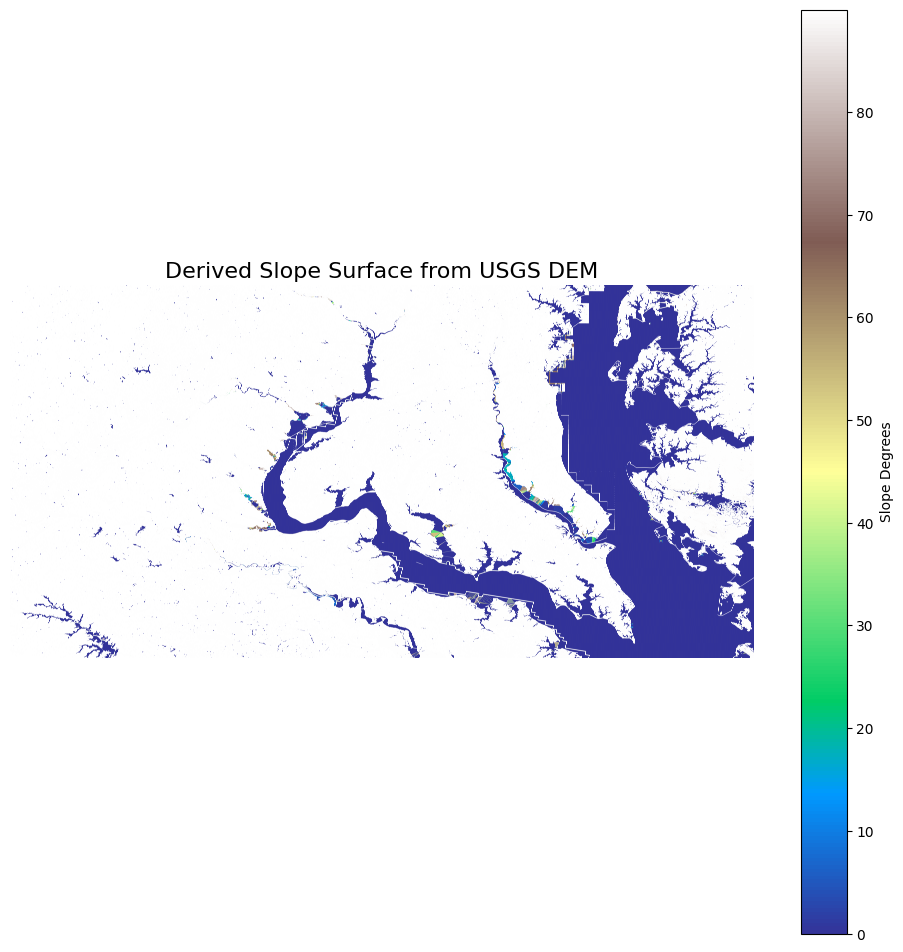

In [53]:
# 12.5.4: Visualize slope raster

fig, ax = plt.subplots(figsize=(12, 12))

slopeImage = ax.imshow(
    slopeDegrees,
    cmap="terrain",
    extent=[
        mergedDemBounds[0],
        mergedDemBounds[2],
        mergedDemBounds[1],
        mergedDemBounds[3]
    ]
)

ax.set_title(
    "Derived Slope Surface from USGS DEM",
    fontsize=16
)

ax.set_axis_off()

plt.colorbar(
    slopeImage,
    ax=ax,
    label="Slope Degrees"
)

plt.show()

### Slope Visualization Observation

The slope raster shows terrain steepness across the DEM mosaic covering the Washington, DC region.

Higher slope values represent steeper terrain, while lower values represent flatter areas.

This raster will be used later as a terrain constraint layer to support terrain-aware accessibility scoring.

In [54]:
# 12.5.5: Save slope raster to processed data folder

slopeOutputPath = DATA_PROCESSED / "dc_slope_degrees.tif"

slopeProfile = firstDem.profile.copy()
slopeProfile.update(
    {
        "driver": "GTiff",
        "height": slopeDegrees.shape[0],
        "width": slopeDegrees.shape[1],
        "transform": mergedDemTransform,
        "count": 1,
        "dtype": "float32"
    }
)

with rasterio.open(slopeOutputPath, "w", **slopeProfile) as dst:
    dst.write(slopeDegrees.astype("float32"), 1)

print(f"Slope raster saved to: {slopeOutputPath}")

Slope raster saved to: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/data/processed/dc_slope_degrees.tif


### Slope Raster Output

The derived slope raster is saved as a GeoTIFF for reproducibility and future analysis.

This output can be reused in:

- terrain classification
- accessibility scoring
- QGIS visualization
- raster-vector overlay workflows
- future portfolio enhancements

## 12.6 Terrain Classification

The derived slope raster is classified into generalized terrain categories to simplify terrain interpretation and support terrain-aware accessibility analysis.

Classifying continuous slope values into discrete terrain groups improves:

- interpretability
- accessibility scoring
- visualization clarity
- infrastructure suitability analysis

The terrain classes are intended to represent generalized accessibility difficulty rather than precise engineering-grade mobility constraints.

### 12.6.1 Terrain Classification Thresholds

The slope raster will be classified into three generalized terrain categories:

| Terrain Class | Slope Range |
|---|---|
| Flat Terrain | 0–5 degrees |
| Moderate Terrain | 5–15 degrees |
| Steep Terrain | Greater than 15 degrees |

These thresholds are simplified exploratory categories designed for accessibility modeling and visualization purposes.

In [55]:
# 12.6.1: Create terrain classification raster

terrainClasses = np.select(
    [
        slopeDegrees <= 5,
        (slopeDegrees > 5) & (slopeDegrees <= 15),
        slopeDegrees > 15
    ],
    [
        1,
        2,
        3
    ],
    default=0
)

print("Terrain classification completed.")

Terrain classification completed.


### Terrain Classification Logic

The terrain raster is classified using threshold-based categorization.

Classification values represent:

- 1 = flat terrain
- 2 = moderate terrain
- 3 = steep terrain

This simplified terrain model supports later accessibility scoring workflows.

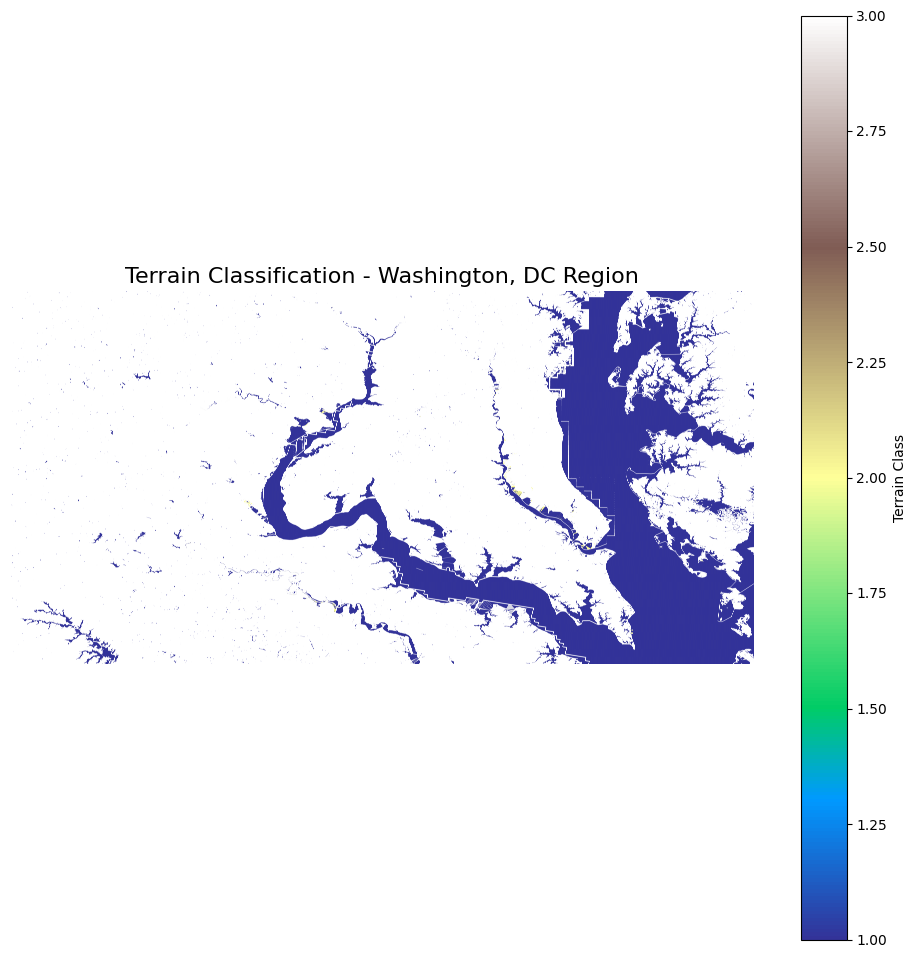

In [56]:
# 12.6.2: Visualize terrain classification

fig, ax = plt.subplots(figsize=(12, 12))

terrainImage = ax.imshow(
    terrainClasses,
    cmap="terrain",
    extent=[
        mergedDemBounds[0],
        mergedDemBounds[2],
        mergedDemBounds[1],
        mergedDemBounds[3]
    ]
)

ax.set_title(
    "Terrain Classification - Washington, DC Region",
    fontsize=16
)

ax.set_axis_off()

plt.colorbar(
    terrainImage,
    ax=ax,
    label="Terrain Class"
)

plt.show()

### Terrain Classification Observation

The classified terrain surface highlights generalized terrain variability across the DEM mosaic.

Most of the Washington, DC region appears relatively flat to moderately sloped, while steeper terrain areas are more limited and spatially concentrated.

These terrain classes will later support terrain-aware accessibility scoring and underserved-area prioritization.

In [57]:
# 12.6.3: Calculate terrain class distribution

uniqueClasses, classCounts = np.unique(
    terrainClasses,
    return_counts=True
)

terrainDistribution = pd.DataFrame(
    {
        "terrainClass": uniqueClasses,
        "cellCount": classCounts
    }
)

terrainDistribution

,terrainClass,cellCount
0,1,47333193
1,2,161734
2,3,186174017


### Terrain Distribution Analysis

Summarizing terrain class distribution provides a quantitative overview of terrain conditions across the study area.

Terrain distribution metrics can later support:
- accessibility weighting
- infrastructure suitability analysis
- terrain-aware prioritization
- comparative regional analysis

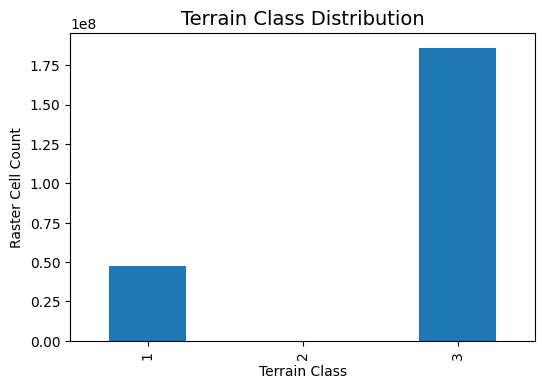

In [58]:
# 12.6.4: Visualize terrain class distribution

fig, ax = plt.subplots(figsize=(6, 4))

terrainDistribution.plot.bar(
    x="terrainClass",
    y="cellCount",
    ax=ax,
    legend=False
)

ax.set_title(
    "Terrain Class Distribution",
    fontsize=14
)

ax.set_xlabel("Terrain Class")
ax.set_ylabel("Raster Cell Count")

plt.show()

In [59]:
# 12.6.5: Export terrain classification raster

terrainOutputPath = (
    DATA_PROCESSED /
    "dc_terrain_classes.tif"
)

terrainProfile = slopeProfile.copy()
terrainProfile.update(
    {
        "driver": "GTiff",
        "height": terrainClasses.shape[0],
        "width": terrainClasses.shape[1],
        "transform": mergedDemTransform,
        "count": 1,
        "dtype": "uint8",
        "nodata": 0
    }
)

with rasterio.open(
    terrainOutputPath,
    "w",
    **terrainProfile
) as dst:
    dst.write(
        terrainClasses.astype("uint8"),
        1
    )

print(f"Terrain classification raster saved to: {terrainOutputPath}")

Terrain classification raster saved to: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/data/processed/dc_terrain_classes.tif


### Terrain Raster Export Note

The terrain classification raster is saved as an unsigned 8-bit integer raster because the class values are small categorical values.

The nodata value is set to 0 because valid terrain classes begin at 1:

- 1 = flat terrain
- 2 = moderate terrain
- 3 = steep terrain

This avoids carrying the DEM nodata value into a categorical raster where it would fall outside the valid `uint8` range.

## 13. Terrain-Aware Priority Scoring Model <a id='13-terrain-aware-priority-scoring-model'></a>

This section creates an exploratory priority scoring model for EV charging infrastructure expansion.

The goal is to combine initial accessibility gaps with terrain considerations so candidate areas can be ranked for further planning review.

This is not a final engineering site-selection model. It is a transparent GIS decision-support workflow that demonstrates how accessibility, terrain, and infrastructure gaps can be combined in a reproducible analysis.

### 13.1 Scoring Model Design

The initial priority scoring model uses two main factors:

| Factor | Purpose |
|---|---|
| Underserved area size | Larger uncovered areas may represent broader accessibility gaps |
| Terrain difficulty | Steeper terrain may reduce practical accessibility and increase planning complexity |

In this version, terrain difficulty is included as a placeholder score. A future version should replace this placeholder with zonal statistics calculated from the terrain classification raster.

In [60]:
# 13.1: Prepare underserved areas for priority scoring

priorityAreasGdf = underservedAreasGdf.copy()

priorityAreasGdf["areaSqKm"] = (
    priorityAreasGdf.geometry.area / 1_000_000
)

priorityAreasGdf.head()

,geometry,areaSqKm
0,"MULTIPOLYGON (((318790.998 4309119.575, 318817...",37.023048


### 13.2 Area-Based Priority Component

Area is used as an initial proxy for accessibility gap size.

Larger uncovered polygons may represent broader regions outside estimated EV charging coverage. These areas can be prioritized for deeper planning review, especially after official boundaries and population data are added.

In [61]:
# 13.2: Normalize underserved area size

maxAreaSqKm = priorityAreasGdf["areaSqKm"].max()

priorityAreasGdf["areaScore"] = (
    priorityAreasGdf["areaSqKm"] / maxAreaSqKm
)

priorityAreasGdf[["areaSqKm", "areaScore"]].head()

,areaSqKm,areaScore
0,37.023048,1.0


### 13.3 Terrain Score Placeholder

The terrain classification raster has been created, but a full raster-to-vector zonal statistics workflow has not yet been applied.

To avoid overstating the current analysis, this notebook uses a placeholder terrain score. This keeps the scoring model structure visible while clearly documenting that future versions should calculate terrain influence directly from the classified terrain raster.

In [62]:
# 13.3: Add terrain score placeholder

priorityAreasGdf["terrainScore"] = 0.5

priorityAreasGdf[["areaSqKm", "areaScore", "terrainScore"]].head()

,areaSqKm,areaScore,terrainScore
0,37.023048,1.0,0.5


### 13.4 Combined Priority Score

The combined priority score uses a weighted formula:

- area score receives 70 percent weight
- terrain score receives 30 percent weight

This first-stage weighting emphasizes accessibility gap size while reserving space for terrain constraints in the prioritization model.

Because the terrain score is currently a placeholder, the result should be interpreted as an exploratory priority framework rather than a final suitability model.

In [63]:
# 13.4: Calculate combined priority score

AREA_WEIGHT = 0.70
TERRAIN_WEIGHT = 0.30

priorityAreasGdf["priorityScore"] = (
    priorityAreasGdf["areaScore"] * AREA_WEIGHT
    + priorityAreasGdf["terrainScore"] * TERRAIN_WEIGHT
)

priorityAreasGdf[
    ["areaSqKm", "areaScore", "terrainScore", "priorityScore"]
].sort_values(
    "priorityScore",
    ascending=False
).head()

,areaSqKm,areaScore,terrainScore,priorityScore
0,37.023048,1.0,0.5,0.85


### Priority Score Interpretation

Higher priority scores indicate candidate areas that may deserve closer review for EV charging infrastructure expansion.

Because this is an exploratory model, the score should be interpreted as a planning-support indicator rather than a final site-selection result.

Future versions should replace the terrain placeholder with zonal terrain statistics and add additional demand variables such as population density, housing density, vehicle ownership, and equity indicators.

In [64]:
# 13.5: Classify priority levels

priorityAreasGdf["priorityLevel"] = pd.cut(
    priorityAreasGdf["priorityScore"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

priorityAreasGdf[
    ["areaSqKm", "priorityScore", "priorityLevel"]
].sort_values(
    "priorityScore",
    ascending=False
).head()

,areaSqKm,priorityScore,priorityLevel
0,37.023048,0.85,High


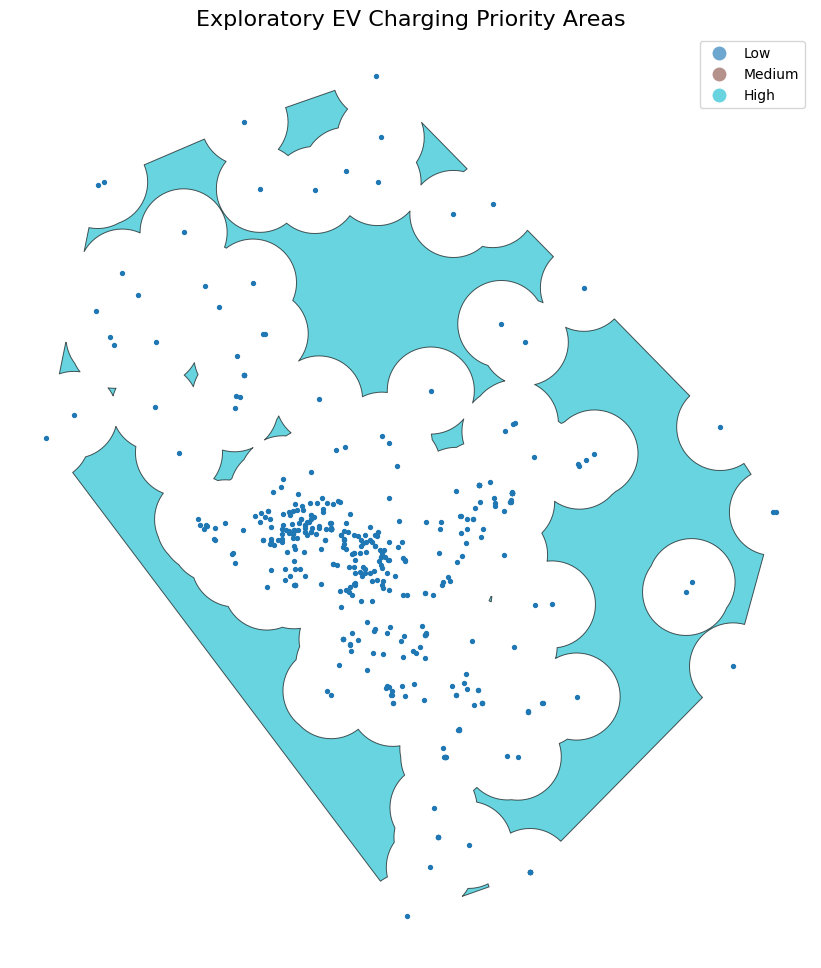

In [65]:
# 13.6: Visualize exploratory priority areas

fig, ax = plt.subplots(figsize=(12, 12))

priorityAreasGdf.plot(
    ax=ax,
    column="priorityLevel",
    legend=True,
    alpha=0.65,
    edgecolor="black",
    linewidth=0.7
)

evStationsProjectedGdf.plot(
    ax=ax,
    markersize=8
)

ax.set_title(
    "Exploratory EV Charging Priority Areas",
    fontsize=16
)

ax.set_axis_off()

plt.show()

### Priority Area Visualization Observation

The map highlights candidate underserved areas grouped by exploratory priority level.

This visualization is useful for communicating where additional planning review may be needed. However, the result should not be interpreted as final site suitability because the model does not yet include official boundaries, population demand, network travel distance, or full terrain zonal statistics.

In [66]:
# 13.7: Export exploratory priority areas

priorityOutputPath = (
    DATA_PROCESSED /
    "dc_ev_priority_areas_exploratory.geojson"
)

priorityAreasGdf.to_file(
    priorityOutputPath,
    driver="GeoJSON"
)

print(f"Priority areas exported to: {priorityOutputPath}")

Priority areas exported to: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/data/processed/dc_ev_priority_areas_exploratory.geojson


### Section Summary

This section created an exploratory priority scoring model for EV charging infrastructure planning.

The current model demonstrates the structure of a reproducible GIS decision-support workflow. It combines accessibility gap size with a terrain placeholder and prepares the project for future improvements using official boundaries, population demand, road-network service areas, and raster-based terrain statistics.

## 14. Analytical Results and Interpretation <a id='14-analytical-results-and-interpretation'></a>

This section summarizes the major findings from the exploratory EV charging accessibility workflow.

The analysis combined:
- EV charging infrastructure data
- accessibility coverage modeling
- underserved-area detection
- DEM-derived terrain analysis
- exploratory prioritization logic

The goal is not to produce a final infrastructure recommendation, but rather to demonstrate a transparent and reproducible GIS decision-support workflow using open-source geospatial tools.

### 14.1 Accessibility Coverage Findings

The accessibility coverage analysis indicates that EV charging infrastructure is spatially concentrated in central and commercially active portions of the Washington, DC region.

Coverage density appears strongest near:
- mixed-use corridors
- commercial activity centers
- higher infrastructure concentration zones

The exploratory buffer analysis also indicates that accessibility coverage becomes less continuous toward outer portions of the current study extent.

In [67]:
# 14.1: Generate infrastructure summary metrics

totalStations = len(evStationsProjectedGdf)

totalCoverageSqKm = round(
    coverageAreaSqKilometers,
    2
)

totalUnderservedSqKm = round(
    underservedAreasGdf.geometry.area.sum() / 1_000_000,
    2
)

summaryMetricsDf = pd.DataFrame(
    {
        "metric": [
            "Total EV Stations",
            "Coverage Area (Sq Km)",
            "Underserved Area (Sq Km)"
        ],
        "value": [
            totalStations,
            totalCoverageSqKm,
            totalUnderservedSqKm
        ]
    }
)

summaryMetricsDf

,metric,value
0,Total EV Stations,412.00
1,Coverage Area (Sq Km),101.82
2,Underserved Area (Sq Km),37.02


### 14.2 Highest Priority Candidate Areas

The table below highlights the highest-scoring exploratory priority areas identified by the current workflow.

In [68]:
# 14.2: Review highest priority areas

priorityAreasGdf[
    [
        "areaSqKm",
        "priorityScore",
        "priorityLevel"
    ]
].sort_values(
    "priorityScore",
    ascending=False
).head(10)

,areaSqKm,priorityScore,priorityLevel
0,37.023048,0.85,High


### 14.2 Underserved Area Findings

The underserved-area workflow identified multiple candidate regions located outside the estimated accessibility coverage surface.

Because the current workflow uses a temporary convex hull study boundary, the underserved polygons should be interpreted as exploratory accessibility gaps rather than final underserved neighborhoods.

Despite this limitation, the workflow successfully demonstrates:
- spatial difference analysis
- infrastructure gap detection
- exploratory service-area modeling
- accessibility-oriented GIS workflows

### 14.3 Terrain Analysis Findings

The DEM-derived terrain workflow demonstrates how raster GIS analysis can be integrated into infrastructure accessibility studies.

The terrain analysis indicates that:
- much of the Washington, DC region is relatively flat to moderately sloped
- steeper terrain areas are more spatially localized
- terrain conditions may still influence practical accessibility patterns

The workflow also demonstrates:
- raster mosaicing
- slope derivation
- terrain classification
- raster export workflows
- raster quality assurance practices

In [69]:
# 14.3: Review terrain distribution summary

terrainDistribution

,terrainClass,cellCount
0,1,47333193
1,2,161734
2,3,186174017


### 14.4 Priority Scoring Findings

The exploratory priority scoring workflow demonstrates how multiple GIS-derived factors can be combined into a transparent prioritization framework.

The current model combines:
- underserved-area size
- placeholder terrain influence

Although simplified, the workflow establishes a reusable structure for future infrastructure prioritization models incorporating:
- population density
- transportation network accessibility
- equity indicators
- charger demand estimation
- terrain zonal statistics

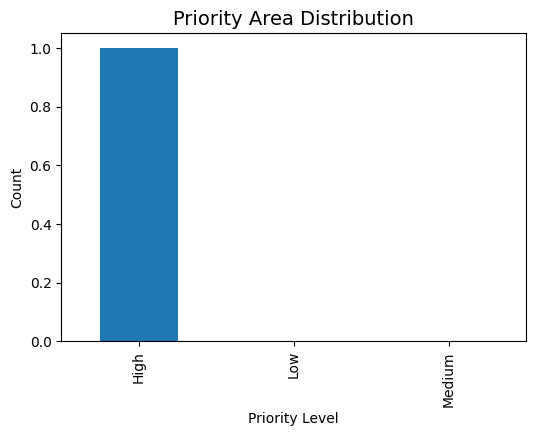

In [70]:
# 14.4: Visualize priority level distribution

fig, ax = plt.subplots(figsize=(6, 4))

priorityAreasGdf["priorityLevel"].value_counts().plot.bar(
    ax=ax
)

ax.set_title(
    "Priority Area Distribution",
    fontsize=14
)

ax.set_xlabel("Priority Level")
ax.set_ylabel("Count")

plt.show()

### 14.5 Engineering and Workflow Findings

From a geospatial engineering perspective, this project demonstrates:

- REST API data acquisition
- structured GIS workflow organization
- CRS-aware spatial analysis
- vector and raster GIS integration
- terrain processing using Rasterio
- reproducible geospatial output management
- exploratory GIS decision-support modeling

The notebook also demonstrates how open-source Python GIS tools can support infrastructure analysis workflows traditionally performed using proprietary GIS platforms.

### 14.6 Future Improvements

Several future enhancements could significantly improve analytical realism:

- replace the temporary study extent with official Washington, DC boundaries
- integrate Census tract demographic data
- implement network-based service-area analysis
- calculate raster zonal statistics for terrain influence
- incorporate charger utilization metrics
- integrate transportation corridor analysis
- develop interactive web-map outputs
- automate the workflow into reusable Python package modules

These enhancements would move the workflow closer to a production-level geospatial planning and infrastructure analysis system.

### Decision-Support Perspective

From an infrastructure planning perspective, the workflow demonstrates how open-source geospatial engineering tools can support exploratory EV charging accessibility analysis.

The notebook establishes a reproducible foundation for:
- accessibility gap detection
- terrain-aware infrastructure analysis
- exploratory prioritization workflows
- future demographic and transportation integration

Although exploratory, the workflow structure is extensible and suitable for future production-oriented enhancements.

## 15. Export Final GIS Layers <a id='15-export-final-gis-layers'></a>

This section exports the final exploratory GIS layers generated throughout the workflow.

Exporting structured geospatial outputs improves:

- interoperability with desktop GIS platforms
- reproducibility of analytical results
- web mapping integration
- downstream spatial analysis workflows
- long-term maintainability of GIS projects

All vector layers are exported as GeoJSON files to maximize portability and compatibility with open-source geospatial tools.

### Output Management Strategy

The workflow separates intermediate analytical outputs from finalized GIS deliverables.

This distinction improves:
- reproducibility
- workflow organization
- debugging efficiency
- downstream interoperability
- long-term maintainability

The project structure follows a modular geospatial engineering workflow commonly used in reproducible GIS analysis pipelines.

In [71]:
# 15.1: Define final export folder

finalOutputFolder = DATA_FINAL

finalOutputFolder.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Final output folder: {finalOutputFolder}")

Final output folder: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/data/final


In [72]:
# 15.2: Export EV charging station layer

finalStationsPath = (
    finalOutputFolder /
    "dc_ev_stations_final.geojson"
)

evStationsProjectedGdf.to_file(
    finalStationsPath,
    driver="GeoJSON"
)

print(f"Exported: {finalStationsPath}")

Exported: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/data/final/dc_ev_stations_final.geojson


In [73]:
# 15.3: Export accessibility coverage layer

finalCoveragePath = (
    finalOutputFolder /
    "dc_ev_coverage_final.geojson"
)

chargerCoverageDissolvedGdf.to_file(
    finalCoveragePath,
    driver="GeoJSON"
)

print(f"Exported: {finalCoveragePath}")

Exported: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/data/final/dc_ev_coverage_final.geojson


In [74]:
# 15.4: Export underserved areas layer

finalUnderservedPath = (
    finalOutputFolder /
    "dc_ev_underserved_final.geojson"
)

underservedAreasGdf.to_file(
    finalUnderservedPath,
    driver="GeoJSON"
)

print(f"Exported: {finalUnderservedPath}")

Exported: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/data/final/dc_ev_underserved_final.geojson


In [75]:
# 15.5: Export exploratory priority areas layer

finalPriorityPath = (
    finalOutputFolder /
    "dc_ev_priority_areas_final.geojson"
)

priorityAreasGdf.to_file(
    finalPriorityPath,
    driver="GeoJSON"
)

print(f"Exported: {finalPriorityPath}")

Exported: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/data/final/dc_ev_priority_areas_final.geojson


### GeoJSON Export Considerations

GeoJSON was selected because it is lightweight, portable, human-readable, and widely supported across open-source GIS and web mapping tools.

However, GeoJSON may become inefficient for very large datasets because it lacks spatial indexing and optimized binary storage.

For larger production-scale geospatial systems, formats such as GeoPackage, FlatGeobuf, or PostGIS-backed workflows may provide better scalability and performance.

### Export Summary

The workflow now produces reusable GIS outputs representing:

- EV charging infrastructure
- accessibility coverage
- underserved areas
- exploratory priority areas
- slope raster outputs
- terrain classification rasters

These outputs can be integrated into:
- desktop GIS workflows
- web mapping systems
- planning dashboards
- infrastructure analysis pipelines

## 16. Interactive Map <a id='16-interactive-map'></a>

This section creates an interactive web map using Folium.

Interactive visualization improves:
- accessibility of analytical results
- stakeholder communication
- exploratory spatial review
- web-based GIS presentation

The interactive map combines:
- EV charging stations
- exploratory priority areas
- accessibility coverage

### Web Mapping Engineering Note

The interactive map demonstrates how exploratory GIS outputs can be integrated into lightweight web mapping workflows using open-source Python tools.

Although Folium provides an efficient approach for exploratory visualization, larger production-scale systems may require:
- vector tiling
- server-side rendering
- spatial indexing
- cloud-hosted GIS services
- client-side performance optimization

These considerations become increasingly important for large-scale geospatial web applications.

In [76]:
# 16.1: Convert projected layers back to WGS84 for web mapping

WEB_CRS = "EPSG:4326"

webStationsGdf = evStationsProjectedGdf.to_crs(WEB_CRS)

webCoverageGdf = chargerCoverageDissolvedGdf.to_crs(WEB_CRS)

webPriorityGdf = priorityAreasGdf.to_crs(WEB_CRS)

print("Web mapping layers prepared successfully.")

Web mapping layers prepared successfully.


### Web Mapping CRS Note

Most web mapping frameworks use geographic coordinate systems based on WGS84 longitude and latitude coordinates.

The projected GIS layers are therefore transformed back into EPSG:4326 before interactive web visualization.

### Coordinate Transformation Consideration

The workflow intentionally maintains projected coordinate systems during spatial analysis and converts layers back to WGS84 only for interactive web visualization.

This distinction is important because:
- projected CRS improves analytical accuracy
- web mapping frameworks expect geographic coordinates
- mixing analytical and visualization CRS workflows can introduce spatial inconsistencies

Explicit CRS management is a critical geospatial engineering practice.

In [77]:
# 16.2: Create interactive Folium map

dcCenter = [38.9072, -77.0369]

interactiveMap = folium.Map(
    location=dcCenter,
    zoom_start=11,
    tiles="CartoDB positron"
)

interactiveMap

In [78]:
# 16.3: Add EV charging stations to interactive map

for _, row in webStationsGdf.iterrows():

    folium.CircleMarker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        radius=4,
        fill=True,
        popup=row.get("station_name", "EV Station")
    ).add_to(interactiveMap)

print("EV charging stations added.")

EV charging stations added.


In [79]:
# 16.4: Add exploratory priority areas

folium.GeoJson(
    webPriorityGdf.to_json(),
    name="Priority Areas"
).add_to(interactiveMap)

print("Priority areas added.")

Priority areas added.


In [80]:
# 16.5: Add accessibility coverage layer

folium.GeoJson(
    webCoverageGdf.to_json(),
    name="Accessibility Coverage"
).add_to(interactiveMap)

print("Coverage layer added.")

Coverage layer added.


In [81]:
# 16.6: Add layer controls

folium.LayerControl().add_to(interactiveMap)

interactiveMap

In [82]:
# 16.7: Add fullscreen map control

from folium.plugins import Fullscreen

Fullscreen().add_to(interactiveMap)

print("Fullscreen control added.")

Fullscreen control added.


In [83]:
# 16.8: Export interactive map

interactiveMapPath = (
    OUTPUTS /
    "dc_ev_accessibility_map.html"
)

interactiveMap.save(
    interactiveMapPath
)

print(f"Interactive map saved to: {interactiveMapPath}")

Interactive map saved to: /Users/nahid/Desktop/QGIS Portfolio/EV Charging Gap Analyzer/outputs/dc_ev_accessibility_map.html


### Interactive Mapping Observation

Interactive web maps improve accessibility and communication of GIS results for both technical and non-technical audiences.

The Folium workflow also demonstrates how Python-based geospatial analysis can integrate with lightweight web-mapping frameworks for exploratory visualization and stakeholder review.

## 17. Key Planning and Infrastructure Findings <a id='17-key-planning-and-infrastructure-findings'></a>

This exploratory workflow demonstrates how open-source geospatial engineering tools can support EV charging accessibility analysis and infrastructure planning.

Key findings include:

- EV charging infrastructure appears spatially concentrated in central portions of the Washington, DC region
- exploratory accessibility gaps appear near outer portions of the current study extent
- terrain conditions vary across the DEM mosaic and may influence practical accessibility
- raster and vector GIS workflows can be integrated into a reproducible planning-support pipeline
- open-source Python GIS tools can support infrastructure analysis workflows traditionally associated with proprietary GIS environments

Although exploratory, the workflow establishes a reusable foundation for future production-oriented accessibility and infrastructure planning systems.

## 18. Limitations <a id='18-limitations'></a>

Several limitations should be acknowledged:

- the study boundary currently uses a temporary convex hull extent
- accessibility is approximated using Euclidean buffers rather than transportation-network travel distance
- terrain influence currently uses a placeholder scoring component
- demographic demand variables are not yet incorporated
- charger utilization and infrastructure capacity are not modeled
- infrastructure suitability has not been validated against zoning or land-use constraints
- the workflow currently emphasizes exploratory planning analysis rather than final engineering site selection

These limitations are intentionally documented to maintain analytical transparency and avoid overstating the results.

### Accessibility Modeling Limitation

The current workflow uses Euclidean buffer analysis rather than transportation-network service areas.

Euclidean buffers provide a simplified accessibility approximation because they measure straight-line distance rather than actual travel distance along roads or pedestrian networks.

Despite this limitation, buffer analysis remains useful for exploratory accessibility modeling because it is computationally efficient, interpretable, and reproducible.

## 19. Future Improvements <a id='19-future-improvements'></a>

Several future enhancements could significantly improve analytical realism and planning value:

- replace the temporary study boundary with official Washington, DC administrative boundaries
- integrate Census tract demographic variables
- implement transportation-network service-area analysis
- calculate terrain zonal statistics from classified slope rasters
- incorporate charger utilization and demand estimation
- integrate transportation corridor analysis
- develop interactive dashboard workflows
- modularize the workflow into reusable Python package components
- automate raster preprocessing workflows
- deploy the workflow within a cloud-based geospatial processing environment

These enhancements would move the project closer to a production-level geospatial infrastructure analysis system.